In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import datetime
import time
import os, sys, glob

import dask.array as da
import netCDF4 as nc
import pyproj
#import pyresample
from io_tool import fill_pattern
import numpy.ma as ma
from matplotlib.pyplot import *
import json
import zarr
import pandas as pd

In [2]:
def prepNCfilesFromVal(start_date, end_date, version, ch, ch_rep):
    
    files = []

    all_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    # Filter out the first 10 days of each month
    #filtered_dates = [date for date in all_dates if date.day <= 10] # Validation data    
    filtered_dates = [date for date in all_dates] # Validation data    
    
    # Convert to list of strings for display
    list_dates = [date.strftime('%Y%m%d') for date in filtered_dates]

    for date in list_dates:
        #filepattern = "/ec/res4/scratch/sbjb/Projects/CERISE/ObsOpData/GNN/%sGHz_static/predictions/%s/Predictions_%s.nc"%(ch[0:2], version,date)
        filepattern = "/ec/res4/scratch/sbjb/Projects/CERISE/ObsOpData/NN/18GHz/Predictions/v03/Predictions_%s.nc"%(date)
        
        files.append(filepattern)
     
    #ds0 = xr.open_mfdataset(files, concat_dim="time", combine="nested")#[varnames]
    ds = xr.open_mfdataset(files, concat_dim="time", combine="nested")#[varnames]
    #ds = ds0.rename({'Target_AMSR2_BT%sV'%ch: 'Target_AMSR2_BT%sV'%ch_rep})
    #ds = ds.rename({'Prediction_AMSR2_BT%sV'%ch: 'Prediction_AMSR2_BT%sV'%ch_rep})       
    #ds = ds.rename({'Prediction_AMSR2_BT%sH'%ch: 'Prediction_AMSR2_BT%sH'%ch_rep})       
    #ds = ds.rename({'Target_AMSR2_BT%sH'%ch: 'Target_AMSR2_BT%sH'%ch_rep})    

    return ds, filtered_dates
    

In [3]:
def filterData():

    data = nc.Dataset('/ec/res4/scratch/sbjb/sfx_data/CERISE_Land_Pv2_dev02/climate/PGD.nc', mode='r')    
    var = data["FRAC_NATURE"][:]    
    data.close()

    return var

In [4]:
# Constants
version = "v19"
ch = "18.7"
ch_rep = "18.7"
pol = "V"
start_date = "2018-06-02"
end_date = "2018-10-01"

In [5]:
#ds = prepNCFiles(version, ch, ch_rep)
ds, filtered_dates = prepNCfilesFromVal(start_date, end_date, version, ch, ch_rep)
#times = pd.date_range(start='2017-06-02', end='2018-05-01', freq='D')
times = filtered_dates
ds = ds.assign_coords(time=times)
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 122, y: 1000, x: 800)
Coordinates:
  * time     (time) datetime64[ns] 976B 2018-06-02 2018-06-03 ... 2018-10-01
Dimensions without coordinates: y, x
Data variables:
    predV    (time, y, x) float64 781MB dask.array<chunksize=(1, 1000, 800), meta=np.ndarray>
    obsV     (time, y, x) float64 781MB dask.array<chunksize=(1, 1000, 800), meta=np.ndarray>


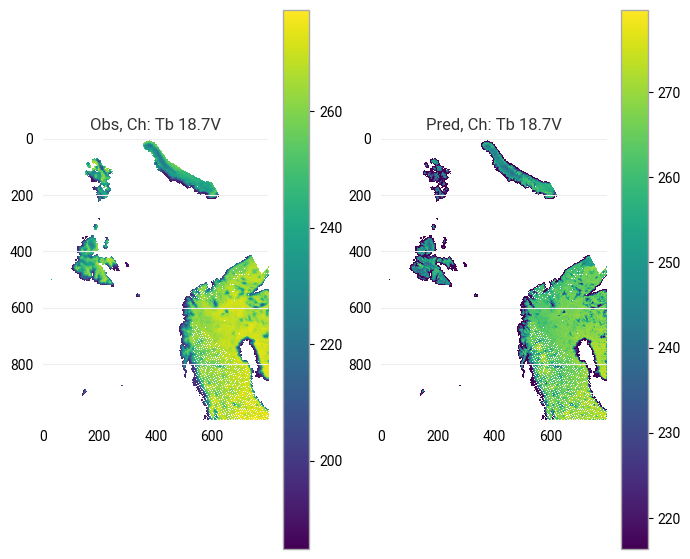

/usr/local/apps/python3/3.12.9-01/lib/python3.12/site-packages/dask/_task_spec.py:755: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [7]:
obs = ds["obsV"].sel(time="2018-06-03", method="nearest").values
mod = ds["predV"].sel(time="2018-06-03", method="nearest").values

fig, ax = plt.subplots(ncols=2)
im1 = ax[0].imshow(obs[:,:], interpolation='none')
im2 = ax[1].imshow(mod[:,:], interpolation='none')
cbar1 = fig.colorbar(im1, ax=ax[0], orientation='vertical')
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='vertical')
ax[0].set_title("Obs, Ch: Tb %s%s"%(ch_rep, pol))
ax[1].set_title("Pred, Ch: Tb %s%s"%(ch_rep, pol))
#cbar1.set_label('Intensity (Plot 1)')
#plt.savefig("Figs/%s/obs_vs_mod_%s.png"%(version,ch_rep))
plt.show()
#plt.close() 

In [238]:
# Mask data

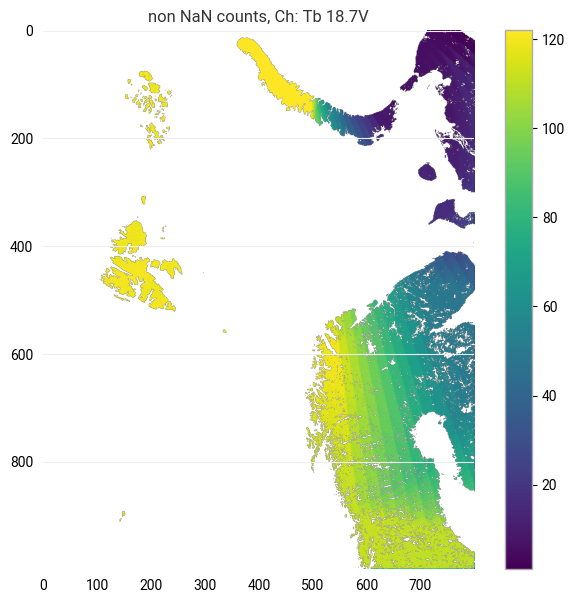

/usr/local/apps/python3/3.12.9-01/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [9]:
frac_nature = filterData()    

msk = frac_nature[::-1,:] < 0.8
ds0 = ds.where(~msk)    

threshold = 10
non_nan_counts = ds0["predV"].count(dim=['time'])

msk1 = non_nan_counts > 0
ds1 = non_nan_counts.where(msk1)   

plt.figure()
plt.title("non NaN counts, Ch: Tb %s%s"%(ch_rep,pol))
plt.imshow(ds1.values[:,:])
plt.colorbar()
#plt.savefig("Figs/%s_val/Nobs_%s%s_%s_%s_03H.png"%(version,ch_rep,pol, start_date, end_date), bbox_inches='tight')
plt.show()



nan


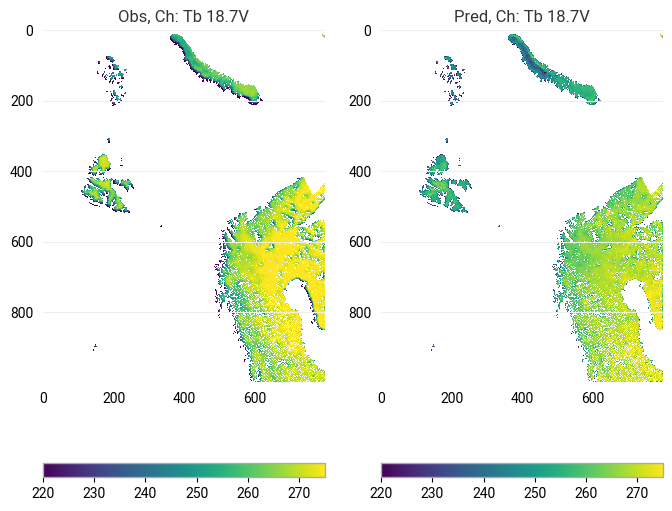

In [10]:
# After masking

obs_m = ds0["obsV"].sel(time="2018-07-05", method="nearest").values
mod_m = ds0["predV"].sel(time="2018-07-05", method="nearest").values

print(np.max(mod_m))

fig, ax = plt.subplots(ncols=2)
im1 = ax[0].imshow(obs_m[:,:], interpolation='none', vmin=220, vmax=275)
im2 = ax[1].imshow(mod_m[:,:], interpolation='none', vmin=220, vmax=275)
cbar1 = fig.colorbar(im1, ax=ax[0], orientation='horizontal',shrink=1)
cbar2 = fig.colorbar(im2, ax=ax[1], orientation='horizontal',shrink=1)
ax[0].set_title("Obs, Ch: Tb %s%s"%(ch_rep, pol))
ax[1].set_title("Pred, Ch: Tb %s%s"%(ch_rep, pol))
#cbar1.set_label('Intensity (Plot 1)')
#plt.savefig("Figs/%s_val/obs_vs_mod_%s.png"%(version,ch_rep))
plt.show()

In [11]:

diff = ds0['obsV'] - ds0['predV'] 

mean_data = diff.mean(dim='time')

squared_diff = diff**2.0
mean_squared_diff = squared_diff.mean(dim='time', skipna=True)
rmse = np.sqrt(mean_squared_diff)

rmse_mean = rmse.mean().values

absolute_error = np.abs(diff)    
mae = absolute_error.mean(dim='time')
mae_mean = mae.mean().values
bias_mean = mean_data.mean().values

correlation = xr.corr(ds0['obsV'], ds0['predV'], dim="time")
#print("Correlation:", correlation.values)
corr_mean = correlation.mean().values


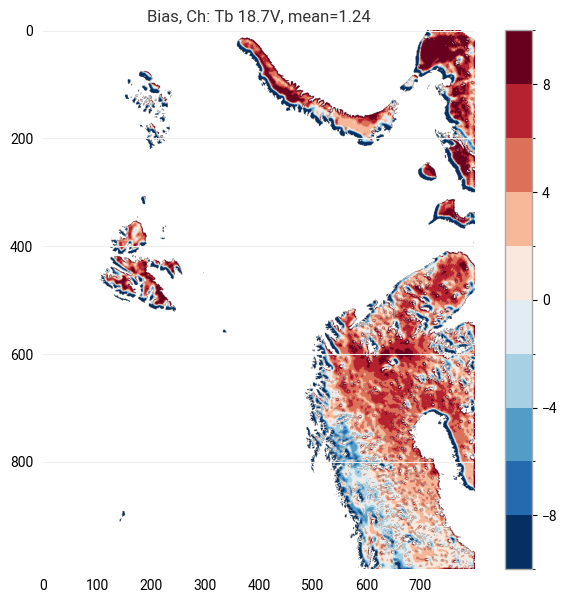

In [12]:
levels = np.linspace(-10., 10., 11)
cmap = plt.get_cmap('RdBu_r')
norm = matplotlib.colors.BoundaryNorm(levels,cmap.N)
  
bias_string = f"{bias_mean:.2f}"

plt.figure()
plt.title("Bias, Ch: Tb %s%s, mean=%s"%(ch_rep,pol,bias_string))
plt.imshow(mean_data[:,:], cmap=cmap, norm=norm, interpolation=None)
plt.colorbar()
#plt.savefig("Figs/%s/Bias_%s%s_%s_%s_03H.png"%(version,ch_rep,pol,start_date, end_date), bbox_inches='tight')
#plt.savefig("Figs/v16_val/Bias_%s%s_%s_%s_03H.png"%(ch_rep,pol,start_date, end_date), bbox_inches='tight')
plt.show()
#plt.savefig("Figs/Bias_18%s_03H_AUG.png"%pol, bbox_inches='tight')
#plt.close()

7.119369118848485


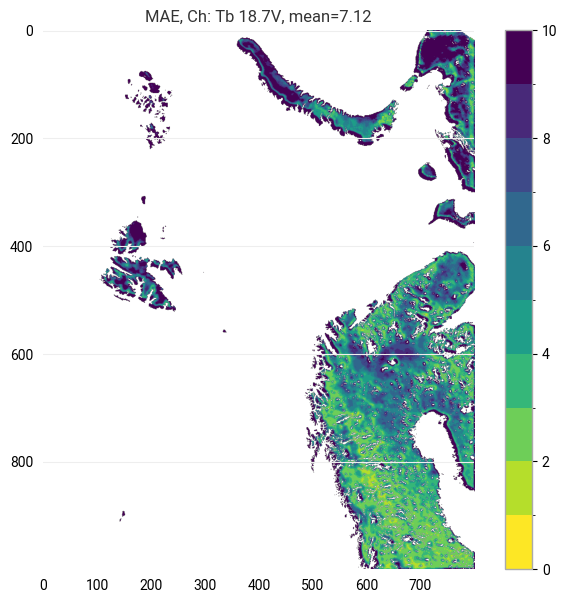

In [13]:
levels = np.linspace(0.0, 10.0, 11)
cmap = plt.get_cmap('viridis_r')
norm = matplotlib.colors.BoundaryNorm(levels,cmap.N)    
print(mae_mean)
string_mean = f"{mae_mean:.2f}"
plt.figure()
plt.title("MAE, Ch: Tb %s%s, mean=%s"%(ch_rep,pol,string_mean))
plt.imshow(mae[:,:], cmap=cmap, norm=norm)
plt.colorbar()
#plt.savefig("Figs/v16_val/mae_%s%s_%s_%s_03H.png"%(ch_rep,pol, start_date, end_date), bbox_inches='tight')
#plt.savefig("Figs/%s/mae_%s%s_%s_%s_03H.png"%(version,ch_rep,pol, start_date, end_date), bbox_inches='tight')
plt.show()
#plt.savefig("Figs/mae_18%s_03H_AUG.png"%pol, bbox_inches='tight')
#plt.close()

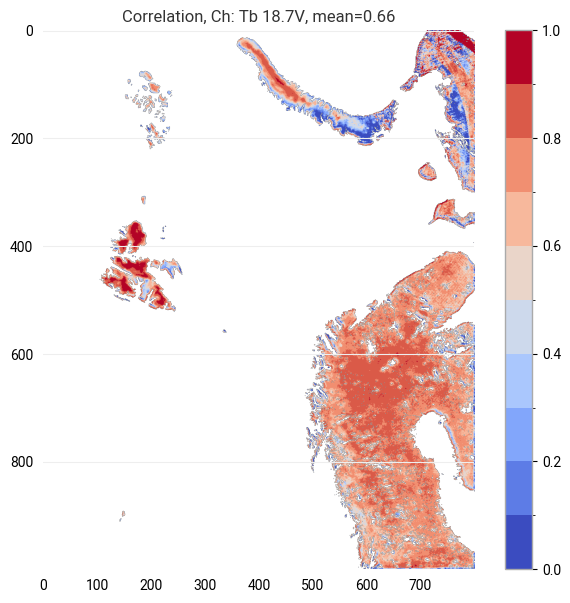

In [14]:
levels = np.linspace(0.0, 1.0, 11)
cmap = plt.get_cmap('coolwarm')
norm = matplotlib.colors.BoundaryNorm(levels,cmap.N)    
string_mean = f"{corr_mean:.2f}"
plt.figure()
plt.title("Correlation, Ch: Tb %s%s, mean=%s"%(ch_rep,pol,string_mean))
plt.imshow(correlation[:,:], cmap=cmap, norm=norm)
plt.colorbar()
#plt.savefig("Figs/%s/corr_%s%s_%s_%s_03H.png"%(version,ch_rep,pol, start_date, end_date), bbox_inches='tight')
#plt.savefig("Figs/v16_val/corr_%s%s_%s_%s_03H.png"%(ch_rep,pol, start_date, end_date), bbox_inches='tight')
plt.show()

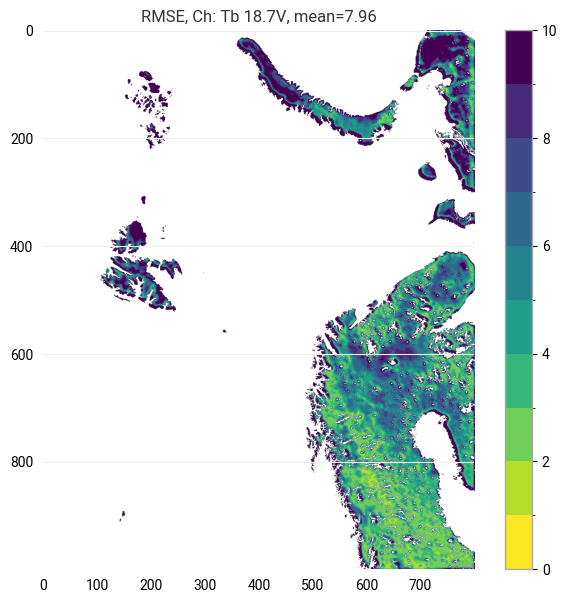

In [15]:
levels = np.linspace(0.0, 10.0, 11)
cmap = plt.get_cmap('viridis_r')
norm = matplotlib.colors.BoundaryNorm(levels,cmap.N)    

string_mean = f"{rmse_mean:.2f}"
plt.figure()
plt.title("RMSE, Ch: Tb %s%s, mean=%s"%(ch_rep,pol,string_mean))
plt.imshow(mae[:,:], cmap=cmap, norm=norm)
plt.colorbar()
#plt.savefig("Figs/%s/rmse_%s%s_%s_%s_03H.png"%(version,ch_rep,pol, start_date, end_date), bbox_inches='tight')
#plt.savefig("Figs/v16_val/rmse_%s%s_%s_%s_03H.png"%(ch_rep,pol, start_date, end_date), bbox_inches='tight')
plt.show()
#plt.savefig("Figs/mae_18%s_03H_AUG.png"%pol, bbox_inches='tight')
#plt.close()

In [245]:
# Domain average statistics

In [18]:
print(diff)

diff_1d = diff.stack(z=("x", "y"),create_index=False)

# Bias
domain_mean = diff_1d.mean(dim='z', skipna=True)

# MAE
absolute_error_domain = np.abs(diff_1d)    
mae_domain = absolute_error_domain.mean(dim='z', skipna=True)

filtered_data = mae_domain.dropna(dim="time")


<xarray.DataArray (time: 122, y: 1000, x: 800)> Size: 781MB
dask.array<sub, shape=(122, 1000, 800), dtype=float64, chunksize=(1, 1000, 800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 976B 2018-06-02 2018-06-03 ... 2018-10-01
Dimensions without coordinates: y, x


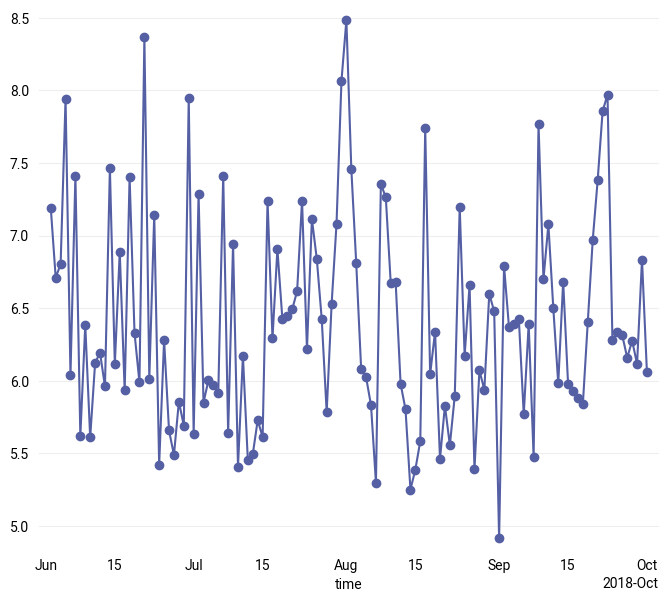

In [21]:
filtered_data.plot(marker='o')

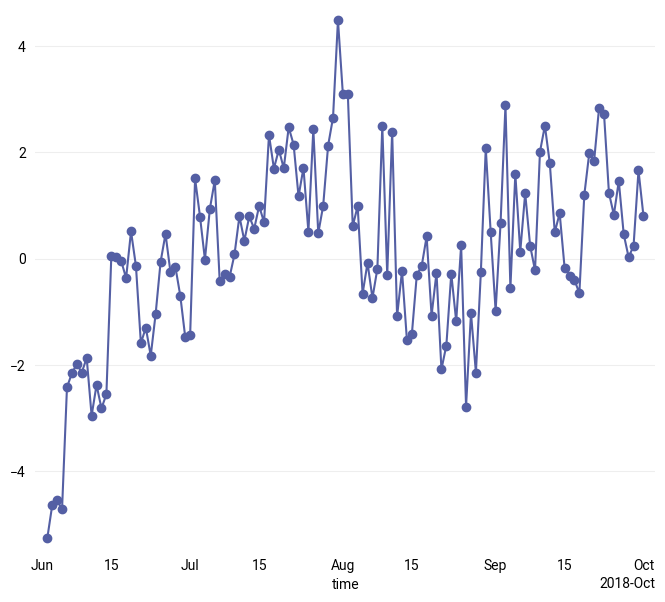

In [20]:
domain_mean.plot(marker='o')

In [24]:
ds_sfx = readSFX(start_date, end_date)
print(ds_sfx)

<xarray.Dataset> Size: 704MB
Dimensions:       (time: 1, yy: 1000, xx: 800, Number_of_Patches: 2)
Dimensions without coordinates: time, yy, xx, Number_of_Patches
Data variables: (12/123)
    VERSION       (time) int32 4B 8
    BUG           (time) int32 4B 1
    STORAGETYPE   (time) |S40 40B b'ALL                                     '
    DIM_FULL      (time) int32 4B 800000
    WRITE_EXT     (time) |S1 1B b'F'
    SPLIT_PATCH   (time) |S1 1B b'F'
    ...            ...
    SNOWLIQ10     (time, Number_of_Patches, yy, xx) float32 6MB dask.array<chunksize=(1, 2, 1000, 800), meta=np.ndarray>
    SNOWTEMP10    (time, Number_of_Patches, yy, xx) float32 6MB dask.array<chunksize=(1, 2, 1000, 800), meta=np.ndarray>
    SNOWLIQ11     (time, Number_of_Patches, yy, xx) float32 6MB dask.array<chunksize=(1, 2, 1000, 800), meta=np.ndarray>
    SNOWTEMP11    (time, Number_of_Patches, yy, xx) float32 6MB dask.array<chunksize=(1, 2, 1000, 800), meta=np.ndarray>
    SNOWLIQ12     (time, Number_of_Patche

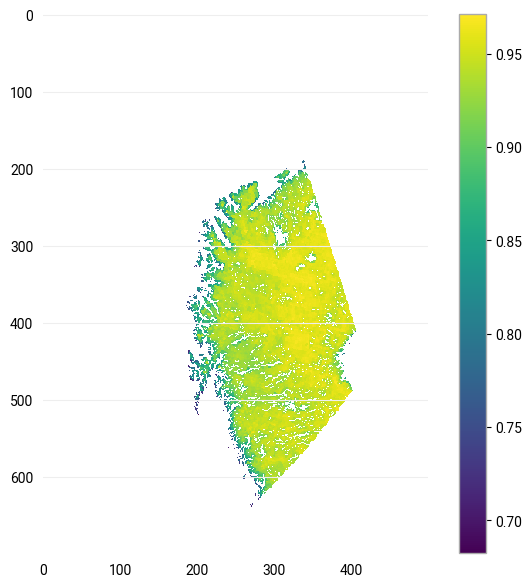

In [31]:
times = filtered_dates
#ds_sfx = ds_sfx.assign_coords(time=times)
ts = ds_sfx["TS_ISBA"].isel(time=0).values

mod_m = ds0["Prediction_AMSR2_BT%s%s"%(ch_rep, pol)].sel(time="2017-08-04", method="nearest").values

emiss = mod_m/ts[::-1,:]

fig, ax = plt.subplots(ncols=1)
#im1 = ax.imshow(ts[::-1,:], interpolation='none')
#im1 = ax.imshow(mod_m[:,:], interpolation='none')
im1 = ax.imshow(emiss[300:,300:], interpolation='none')
cbar1 = fig.colorbar(im1, ax=ax, orientation='vertical')
#ax[0].set_title("Obs, Ch: Tb %s%s"%(ch_rep, pol))
#cbar1.set_label('Intensity (Plot 1)')
#plt.savefig("Figs/%s_val/obs_vs_mod_%s.png"%(version,ch_rep))
plt.show()
#plt.close() 